# RealWorld HAR Dataset — Preprocessing & Exploratory Data Analysis

This notebook loads the raw RealWorld Human Activity Recognition dataset
(15 participants, multiple body-worn sensors, multiple activities), cleans it,
explores it, and produces a single tidy, checkpointed dataframe ready for the
next notebook (windowing + model training).

In [48]:
import re
import io
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

In [49]:
DATASET_PATH = Path("/lustre09/project/6081099/reem2005/DATASET/REALWORLD")
OUTPUT_DIR = Path("/lustre09/project/6081099/reem2005/DATASET/PROCESSED")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_CHECKPOINT = OUTPUT_DIR / "realworld_raw_combined.parquet"
CLEAN_OUTPUT = OUTPUT_DIR / "realworld_clean.parquet"

SENSORS = ["acc", "gyr", "mag"]

print("Dataset path exists?", DATASET_PATH.exists())
print("Output dir          :", OUTPUT_DIR)

Dataset path exists? True
Output dir          : /lustre09/project/6081099/reem2005/DATASET/PROCESSED


In [50]:
def read_sensor_zip(zip_path: Path, sensor: str, participant: str):
    """Read every CSV inside a (possibly nested) sensor zip file and tag
    each row with participant / activity / sensor / position metadata."""
    dfs = []
    activity = zip_path.stem.replace("_csv", "").split("_", 1)[1]

    def process_zip(z: zipfile.ZipFile):
        for file in z.namelist():
            if file.endswith(".csv"):
                position = Path(file).stem
                df = pd.read_csv(z.open(file))
                df["participant"] = participant
                df["activity"] = activity
                df["sensor"] = sensor
                df["position"] = position
                dfs.append(df)
            elif file.endswith(".zip"):
                nested_bytes = z.read(file)
                with zipfile.ZipFile(io.BytesIO(nested_bytes), "r") as nested_z:
                    process_zip(nested_z)

    with zipfile.ZipFile(zip_path, "r") as z:
        process_zip(z)

    if not dfs:
        return None
    return pd.concat(dfs, ignore_index=True)

In [51]:
def load_realworld_dataset(dataset_path: Path, sensors: list):
    """Walk every participant folder, load every sensor zip, and return
    one combined long-format dataframe."""
    all_data = []
    participants = sorted(dataset_path.glob("proband*"))
    print(f"Found {len(participants)} participants")

    for participant_path in participants:
        participant = participant_path.name
        print(f"Processing {participant}...")
        data_dir = participant_path / "data"

        if not data_dir.exists():
            print(f"  Skipping (no data folder: {data_dir})")
            continue

        for sensor in sensors:
            zip_files = sorted(data_dir.glob(f"{sensor}_*_csv.zip"))
            for zip_path in zip_files:
                try:
                    df = read_sensor_zip(zip_path, sensor, participant)
                    if df is None:
                        print(f"  Skipped {zip_path.name} (no csv data found)")
                        continue
                    all_data.append(df)
                    print(f"  Loaded {zip_path.name} -> {df.shape[0]} rows")
                except Exception as e:
                    print(f"  ERROR reading {zip_path}: {e}")

    print("\nCombining all data...")
    final_df = pd.concat(all_data, ignore_index=True)
    print("Done! Final shape:", final_df.shape)
    return final_df

In [52]:
FORCE_RELOAD = False

if RAW_CHECKPOINT.exists() and not FORCE_RELOAD:
    print("Loading from checkpoint:", RAW_CHECKPOINT)
    final_df = pd.read_pickle(RAW_CHECKPOINT)
else:
    final_df = load_realworld_dataset(DATASET_PATH, SENSORS)
    final_df.to_pickle(RAW_CHECKPOINT)
    print("Saved raw checkpoint to:", RAW_CHECKPOINT)

print("Shape:", final_df.shape)
final_df.head()

Found 15 participants
Processing proband1...
  Loaded acc_climbingdown_csv.zip -> 177885 rows
  Loaded acc_climbingup_csv.zip -> 224128 rows
  Loaded acc_jumping_csv.zip -> 30204 rows
  Loaded acc_lying_csv.zip -> 221563 rows
  Loaded acc_running_csv.zip -> 214128 rows
  Loaded acc_sitting_csv.zip -> 230099 rows
  Loaded acc_standing_csv.zip -> 224634 rows
  Loaded acc_walking_csv.zip -> 223486 rows
  Loaded gyr_climbingdown_csv.zip -> 178387 rows
  Loaded gyr_climbingup_csv.zip -> 306425 rows
  Loaded gyr_jumping_csv.zip -> 30276 rows
  Loaded gyr_lying_csv.zip -> 251752 rows
  Loaded gyr_running_csv.zip -> 214656 rows
  Loaded gyr_sitting_csv.zip -> 331897 rows
  Loaded gyr_standing_csv.zip -> 225241 rows
  Loaded gyr_walking_csv.zip -> 223597 rows
  Loaded mag_climbingdown_csv.zip -> 178385 rows
  Loaded mag_climbingup_csv.zip -> 214403 rows
  Loaded mag_jumping_csv.zip -> 30275 rows
  Loaded mag_lying_csv.zip -> 251751 rows
  Loaded mag_running_csv.zip -> 214650 rows
  Loaded mag_s

,id,attr_time,attr_x,attr_y,attr_z,participant,activity,sensor,position
0,1,1435996968010,5.616797,8.064270,0.878073,proband1,climbingdown,acc,acc_climbingdown_chest
1,2,1435996968032,5.589264,8.054693,0.869095,proband1,climbingdown,acc,acc_climbingdown_chest
2,3,1435996968052,5.580884,8.060080,0.908001,proband1,climbingdown,acc,acc_climbingdown_chest
3,4,1435996968073,5.588067,8.033744,0.884657,proband1,climbingdown,acc,acc_climbingdown_chest
4,5,1435996968093,5.583877,8.060678,0.875679,proband1,climbingdown,acc,acc_climbingdown_chest


In [53]:
print("=" * 50)
print("SHAPE & DTYPES")
print("=" * 50)
print("Shape:", final_df.shape)
print()
print(final_df.dtypes)

SHAPE & DTYPES
Shape: (72309356, 9)

id               int64
attr_time        int64
attr_x         float64
attr_y         float64
attr_z         float64
participant        str
activity           str
sensor             str
position           str
dtype: object


In [54]:
print("=" * 50)
print("MEMORY USAGE")
print("=" * 50)
print(final_df.info(memory_usage="deep"))

MEMORY USAGE
<class 'pandas.DataFrame'>
RangeIndex: 72309356 entries, 0 to 72309355
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   attr_time    int64  
 2   attr_x       float64
 3   attr_y       float64
 4   attr_z       float64
 5   participant  str    
 6   activity     str    
 7   sensor       str    
 8   position     str    
dtypes: float64(3), int64(2), str(4)
memory usage: 20.9 GB
None


In [55]:
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = final_df.isnull().sum()
missing_pct = (missing / len(final_df) * 100).round(3)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_report[missing_report["missing_count"] > 0] if missing.sum() > 0 else "No missing values.")

MISSING VALUES
No missing values.


In [56]:
print("=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
n_dupes = final_df.duplicated().sum()
print("Duplicates:", n_dupes)

if n_dupes > 0:
    final_df = final_df.drop_duplicates().reset_index(drop=True)
    print("Dropped duplicates. New shape:", final_df.shape)

DUPLICATE ROWS
Duplicates: 0


In [57]:
print("=" * 50)
print("NUMERIC SUMMARY")
print("=" * 50)
print(final_df.describe())

NUMERIC SUMMARY
                 id     attr_time        attr_x        attr_y        attr_z
count  7.230936e+07  7.230936e+07  7.230936e+07  7.230936e+07  7.230936e+07
mean   1.620824e+04  1.436772e+12  1.251441e+00 -3.530878e+00 -1.167367e+00
std    1.308983e+04  5.582220e+08  1.615305e+01  1.786318e+01  1.205052e+01
min    1.000000e+00  1.435990e+12 -1.435280e+02 -2.336480e+02 -1.751210e+02
25%    6.744000e+03  1.436375e+12 -2.814384e+00 -4.121020e+00 -1.844732e+00
50%    1.475500e+04  1.436622e+12 -5.511064e-03  8.977060e-03 -6.866460e-04
75%    2.348000e+04  1.436985e+12  2.886210e+00  4.116830e+00  1.735796e+00
max    1.918370e+05  1.438347e+12  2.482160e+02  1.525310e+02  1.878120e+02


In [58]:
print("PARTICIPANTS")
print(final_df["participant"].value_counts().sort_index())

print("\nACTIVITIES")
print(final_df["activity"].value_counts())

print("\nSENSORS")
print(final_df["sensor"].value_counts())

print("\nRAW POSITIONS (before cleaning)")
print(final_df["position"].value_counts())

PARTICIPANTS
participant
proband1     4877602
proband10    4465609
proband11    4666565
proband12    4558450
proband13    4621499
proband14    4657528
proband15    4694899
proband2     4412419
proband3     4808969
proband4     5584843
proband5     5188177
proband6     4620250
proband7     5071955
proband8     5303057
proband9     4777534
Name: count, dtype: int64

ACTIVITIES
activity
running         11434454
walking         10335240
climbingup      10300300
lying           10289327
sitting         10235515
standing        10077801
climbingdown     8095920
jumping          1540799
Name: count, dtype: int64

SENSORS
sensor
gyr    24925226
mag    23729121
acc    23655009
Name: count, dtype: int64

RAW POSITIONS (before cleaning)
position
Gyroscope_climbingup_chest            835154
Gyroscope_running_chest               697594
Gyroscope_lying_chest                 575792
Gyroscope_walking_chest               547296
acc_running_thigh                     539012
                              

In [59]:
KNOWN_POSITIONS = ["chest", "forearm", "head", "shin", "thigh", "upperarm", "waist"]

def clean_position(pos: str) -> str:
    pos = pos.lower()
    for p in KNOWN_POSITIONS:
        if p in pos:
            return p
    return pos  # unmatched values pass through unchanged so we can spot them

final_df["position"] = final_df["position"].apply(clean_position)

print("POSITIONS (after cleaning)")
print(final_df["position"].value_counts())

unmatched = set(final_df["position"].unique()) - set(KNOWN_POSITIONS)
if unmatched:
    print("\n⚠️  Unmatched position labels found:", unmatched)
else:
    print("\n✅ All positions matched to the 7 known body locations.")

POSITIONS (after cleaning)
position
chest       11263913
waist       10271361
shin        10224939
upperarm    10173645
head        10165532
thigh       10151831
forearm     10058135
Name: count, dtype: int64

✅ All positions matched to the 7 known body locations.


In [60]:
pivot = final_df.groupby(["participant", "activity"]).size().unstack(fill_value=0)
pivot

activity,climbingdown,climbingup,jumping,lying,running,sitting,standing,walking
participant,,,,,,,,
proband1,534657,744956,90755,725066,643434,792525,675114,671095
proband10,461068,482395,108978,673711,676914,675130,719883,667530
proband11,522868,660915,104830,688879,653325,674109,661865,699774
proband12,512192,655602,106977,657816,650870,658783,648917,667293
proband13,460458,631768,113124,680725,651123,679358,715861,689082
proband14,503543,667468,102459,663168,652369,663698,656123,748700
proband15,538066,613257,99809,695355,710255,678556,661469,698132
proband2,521734,452698,113146,718647,612491,648901,698669,646133
proband3,582601,621540,108234,663559,797360,662470,656089,717116


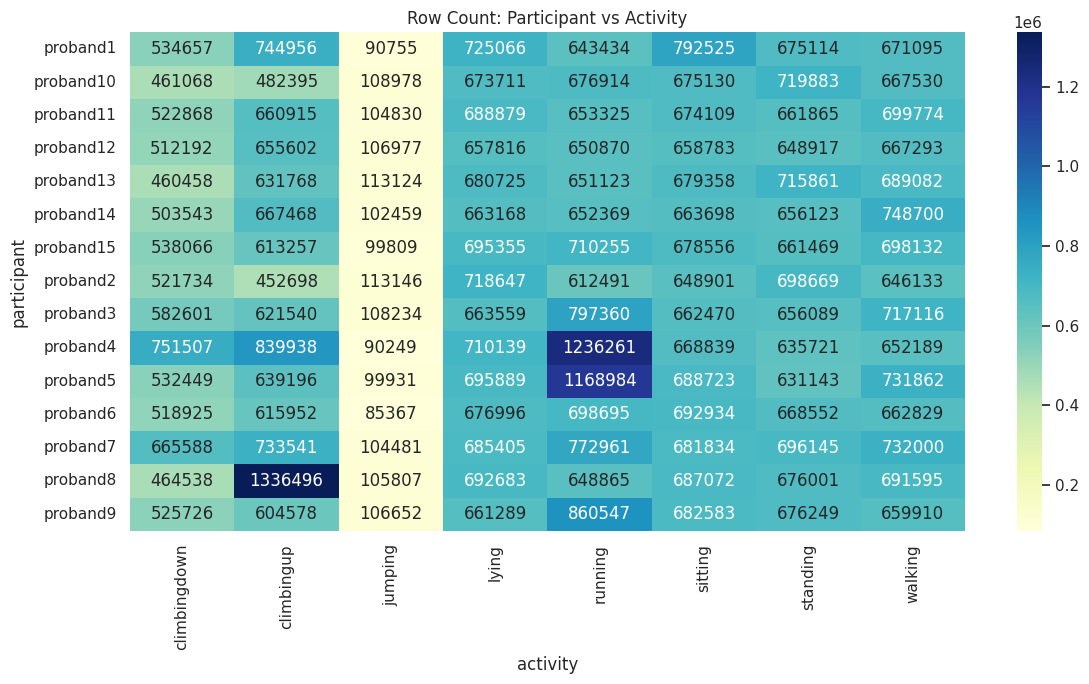

In [33]:
plt.figure(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Row Count: Participant vs Activity")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1280422/307194091.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_counts.index, y=activity_counts.values, palette="viridis")


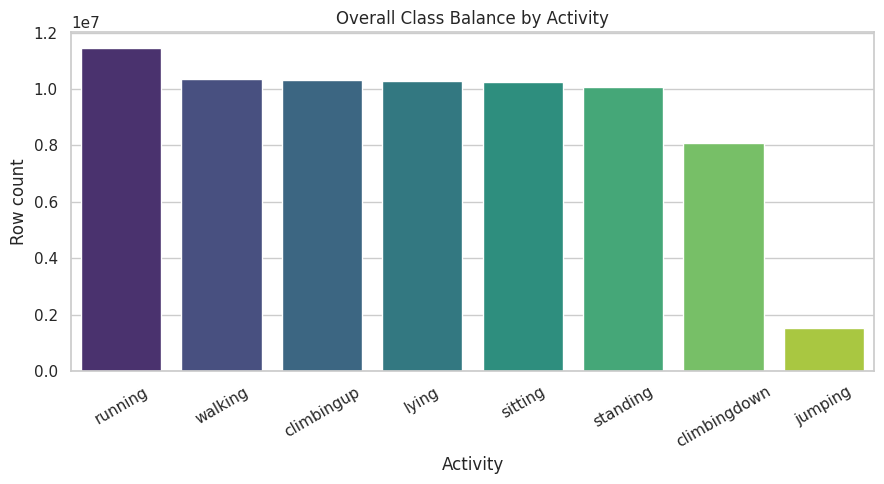

In [34]:
activity_counts = final_df["activity"].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=activity_counts.index, y=activity_counts.values, palette="viridis")
plt.ylabel("Row count")
plt.xlabel("Activity")
plt.title("Overall Class Balance by Activity")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [35]:
def check_sampling_rate(df: pd.DataFrame, sensor: str, n_groups: int = 5, seed: int = 42):
    sub = df[df["sensor"] == sensor]
    groups = sub.groupby(["participant", "activity", "position"])
    sample_keys = pd.Series(list(groups.groups.keys())).sample(
        min(n_groups, len(groups)), random_state=seed
    )
    rows = []
    for key in sample_keys:
        g = groups.get_group(key).sort_values("attr_time")
        deltas = g["attr_time"].diff().dropna()
        if len(deltas) == 0:
            continue
        rows.append({
            "participant": key[0],
            "activity": key[1],
            "position": key[2],
            "n_samples": len(g),
            "median_delta_ms": deltas.median(),
            "std_delta_ms": deltas.std(),
            "implied_hz": 1000 / deltas.median() if deltas.median() > 0 else np.nan,
        })
    return pd.DataFrame(rows)

# تشغيلها على كل حساس لحاله وطباعة النتيجة
sampling_reports = {}

for sensor in SENSORS:
    print(f"\n=== {sensor.upper()} ===")
    report = check_sampling_rate(final_df, sensor=sensor, n_groups=8)
    sampling_reports[sensor] = report
    print(report)


=== ACC ===
  participant    activity position  n_samples  median_delta_ms  std_delta_ms  \
0   proband12    standing    chest      30870             20.0     28.504473   
1    proband9    standing    chest      32169             20.0     31.706200   
2   proband10       lying  forearm      32033             20.0     32.886962   
3   proband10  climbingup    thigh      22969             20.0     31.689136   
4    proband7  climbingup     head      31982             20.0   8171.166064   
5    proband8     sitting     head      32697             20.0     30.253486   
6    proband1     running     head      30615             20.0     30.411579   
7   proband14  climbingup    thigh      31152             20.0   7044.658812   

   implied_hz  
0        50.0  
1        50.0  
2        50.0  
3        50.0  
4        50.0  
5        50.0  
6        50.0  
7        50.0  

=== GYR ===
  participant    activity position  n_samples  median_delta_ms  std_delta_ms  \
0   proband12    standing    

In [36]:
def flag_outliers(df: pd.DataFrame, sensor: str, iqr_multiplier: float = 3.0):
    sub = df[df["sensor"] == sensor].copy()
    for axis in ["attr_x", "attr_y", "attr_z"]:
        q1, q3 = sub[axis].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - iqr_multiplier * iqr, q3 + iqr_multiplier * iqr
        sub[f"{axis}_outlier"] = (sub[axis] < lower) | (sub[axis] > upper)
    sub["any_outlier"] = sub[["attr_x_outlier", "attr_y_outlier", "attr_z_outlier"]].any(axis=1)
    return sub

# تشغيلها على كل حساس وتجميع ملخص
outlier_summary = []

for sensor in SENSORS:
    flagged = flag_outliers(final_df, sensor=sensor)
    pct = flagged["any_outlier"].mean() * 100
    outlier_summary.append({"sensor": sensor, "outlier_pct": pct})
    print(f"{sensor.upper()}: {pct:.3f}% rows flagged as outliers")

pd.DataFrame(outlier_summary)

ACC: 0.945% rows flagged as outliers
GYR: 28.600% rows flagged as outliers
MAG: 0.018% rows flagged as outliers


,sensor,outlier_pct
0,acc,0.944887
1,gyr,28.599600
2,mag,0.018050


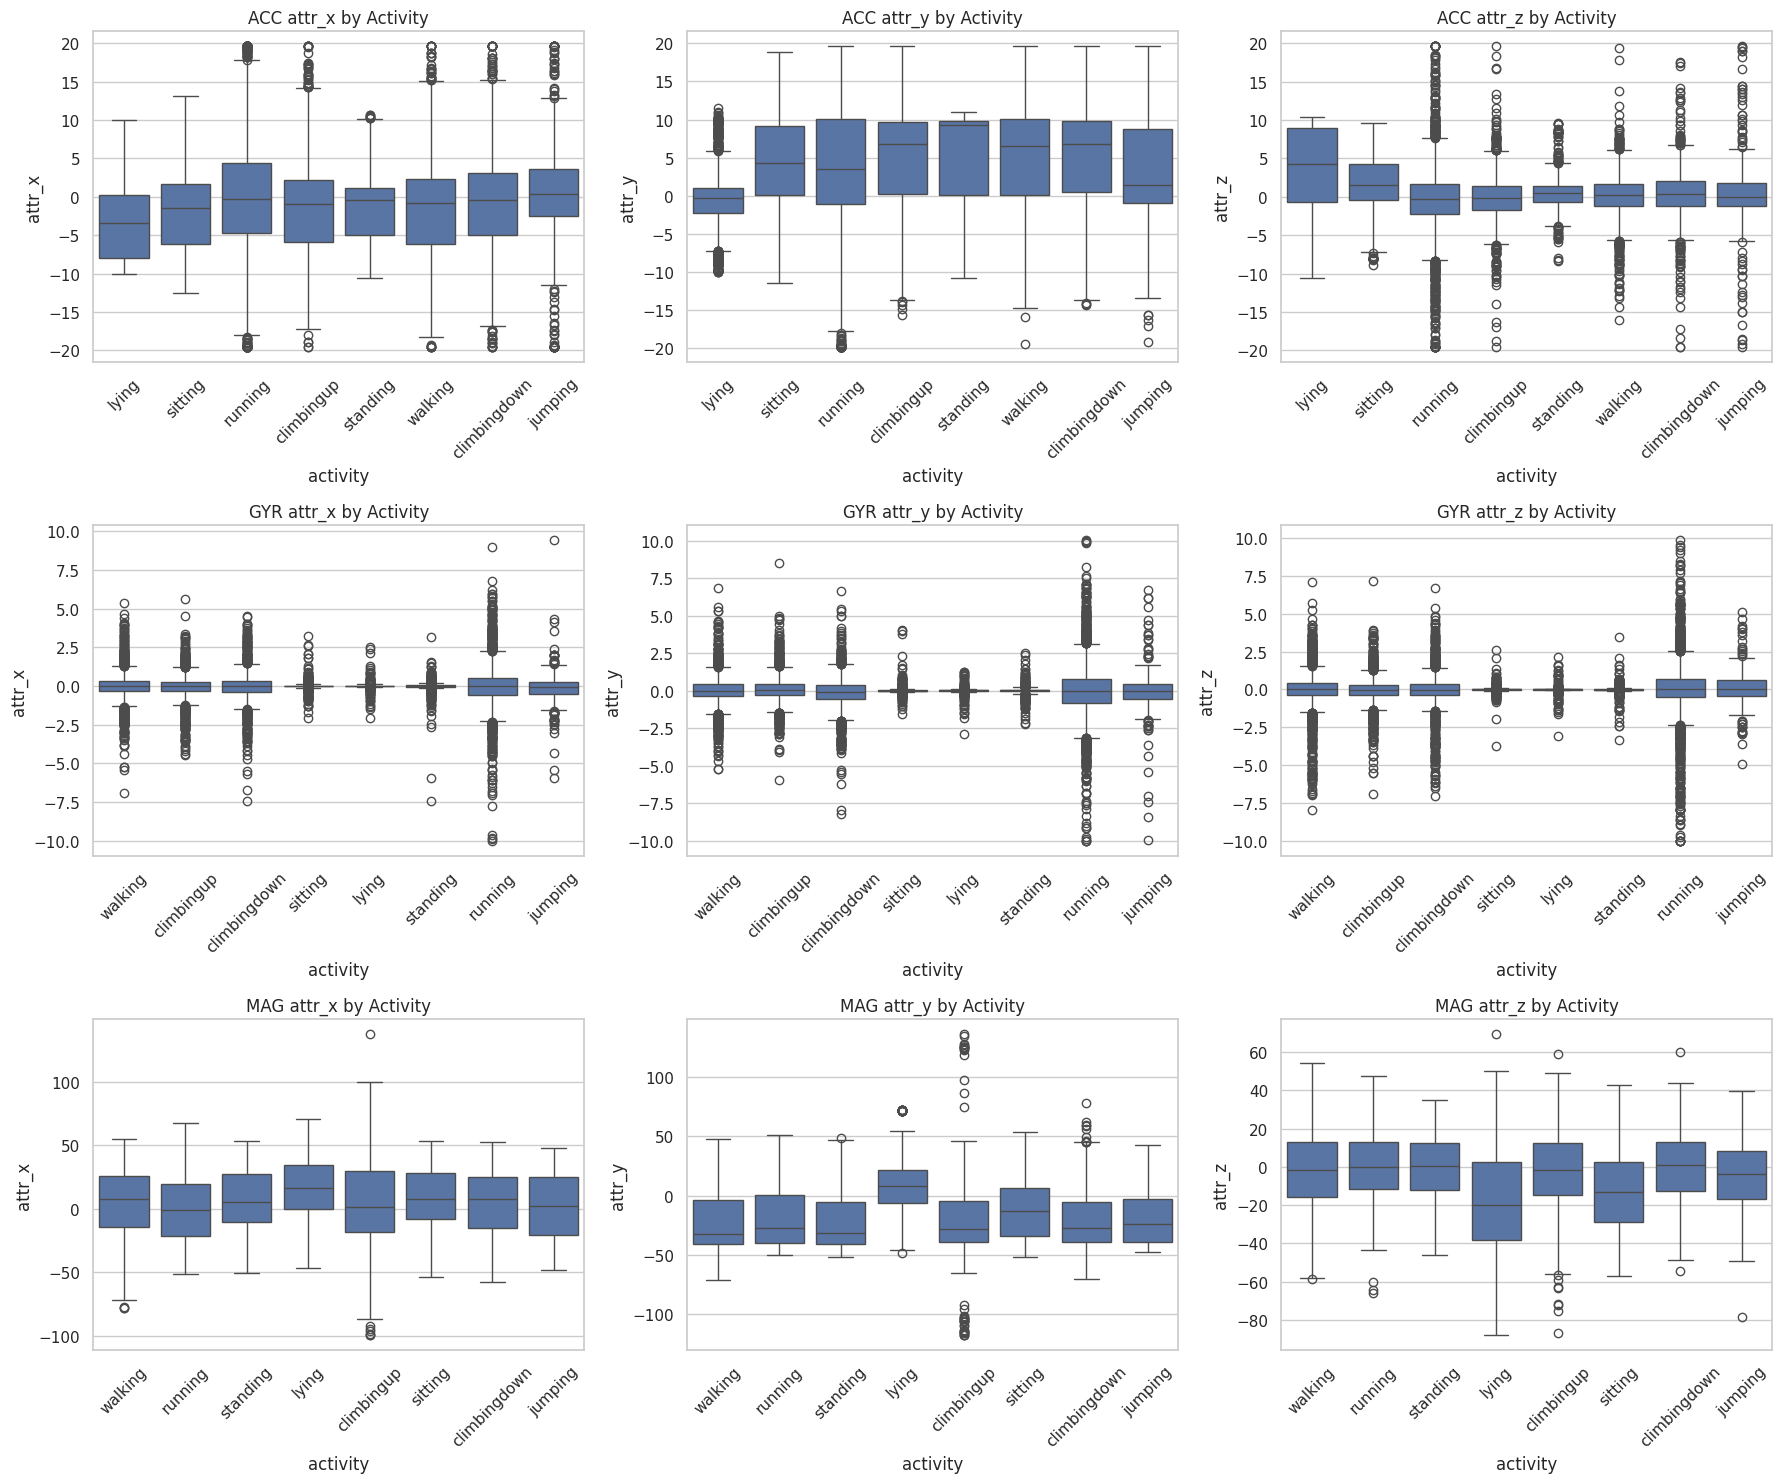

In [37]:
sample = final_df[final_df["sensor"].isin(SENSORS)].groupby("sensor").sample(
    n=15000, random_state=1, replace=True
)

fig, axes = plt.subplots(len(SENSORS), 3, figsize=(18, 5 * len(SENSORS)))

for row, sensor in enumerate(SENSORS):
    sensor_sample = sample[sample["sensor"] == sensor]
    for col, axis in enumerate(["attr_x", "attr_y", "attr_z"]):
        sns.boxplot(data=sensor_sample, x="activity", y=axis, ax=axes[row, col])
        axes[row, col].set_title(f"{sensor.upper()} {axis} by Activity")
        axes[row, col].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

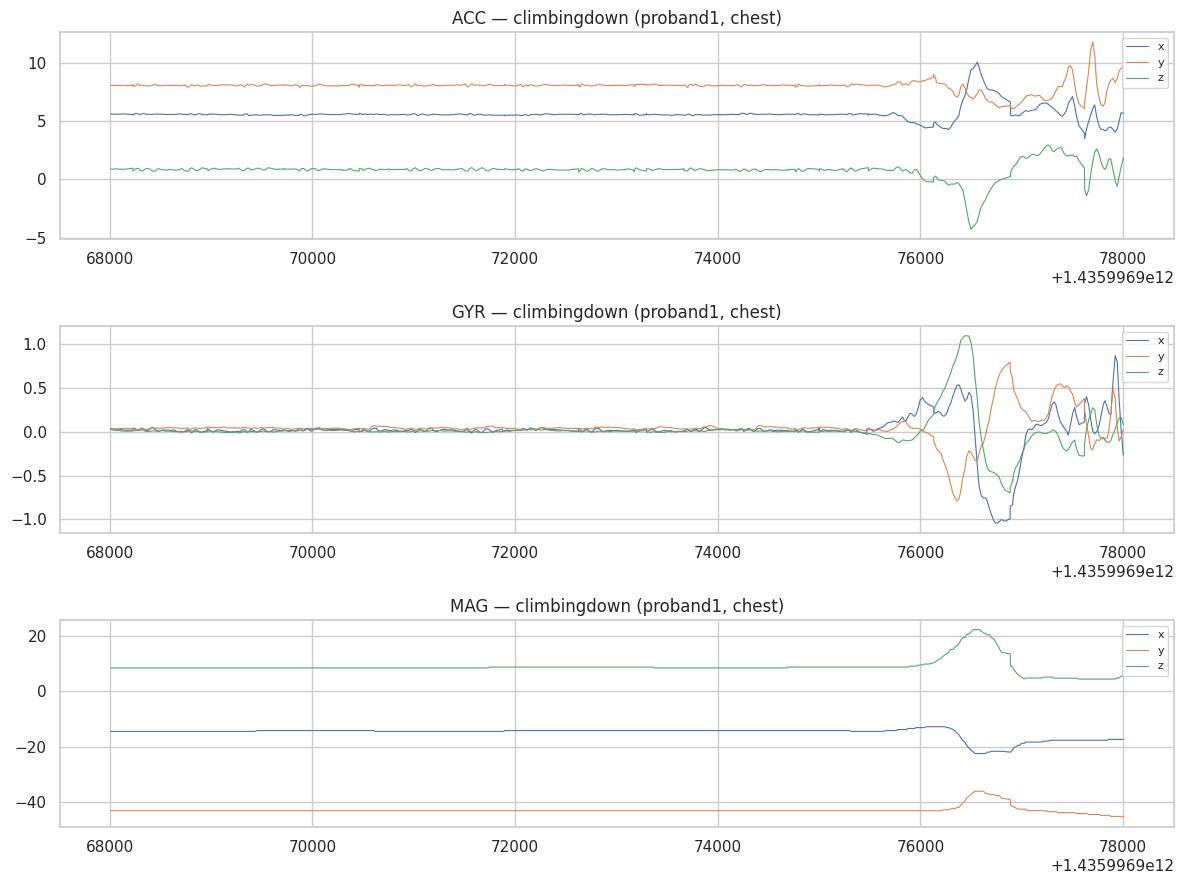

In [38]:
def plot_all_sensors_timeseries(df, participant, position, activity, sensors=SENSORS, n_points=500):
    fig, axes = plt.subplots(len(sensors), 1, figsize=(12, 3 * len(sensors)))
    if len(sensors) == 1:
        axes = [axes]

    for ax, sensor in zip(axes, sensors):
        seg = df[
            (df["participant"] == participant)
            & (df["position"] == position)
            & (df["activity"] == activity)
            & (df["sensor"] == sensor)
        ].sort_values("attr_time").head(n_points)

        if seg.empty:
            ax.set_title(f"{sensor} — no data found")
            continue

        ax.plot(seg["attr_time"], seg["attr_x"], label="x", linewidth=0.8)
        ax.plot(seg["attr_time"], seg["attr_y"], label="y", linewidth=0.8)
        ax.plot(seg["attr_time"], seg["attr_z"], label="z", linewidth=0.8)
        ax.set_title(f"{sensor.upper()} — {activity} ({participant}, {position})")
        ax.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

plot_all_sensors_timeseries(
    final_df,
    participant=final_df["participant"].iloc[0],
    position="chest",
    activity=final_df["activity"].unique()[0],
)

In [43]:
final_df = final_df.sort_values(
    by=["participant", "sensor", "position", "attr_time"]
).reset_index(drop=True)

print("Final shape:", final_df.shape)
final_df.head()

Final shape: (72309356, 9)


,id,attr_time,attr_x,attr_y,attr_z,participant,activity,sensor,position
0,1,1435996968010,5.616797,8.064270,0.878073,proband1,climbingdown,acc,acc_climbingdown_chest
1,2,1435996968032,5.589264,8.054693,0.869095,proband1,climbingdown,acc,acc_climbingdown_chest
2,3,1435996968052,5.580884,8.060080,0.908001,proband1,climbingdown,acc,acc_climbingdown_chest
3,4,1435996968073,5.588067,8.033744,0.884657,proband1,climbingdown,acc,acc_climbingdown_chest
4,5,1435996968093,5.583877,8.060678,0.875679,proband1,climbingdown,acc,acc_climbingdown_chest


In [45]:
# Reduce memory consumption before saving
for col in ["participant", "activity", "sensor", "position"]:
    final_df[col] = final_df[col].astype("category")

for col in ["attr_x", "attr_y", "attr_z"]:
    final_df[col] = final_df[col].astype("float32")

final_df["attr_time"] = final_df["attr_time"].astype("int64")  # يبقى زي ما هو، مهم للدقة الزمنية

print(final_df.info(memory_usage="deep"))

<class 'pandas.DataFrame'>
RangeIndex: 72309356 entries, 0 to 72309355
Data columns (total 9 columns):
 #   Column       Dtype   
---  ------       -----   
 0   id           int64   
 1   attr_time    int64   
 2   attr_x       float32 
 3   attr_y       float32 
 4   attr_z       float32 
 5   participant  category
 6   activity     category
 7   sensor       category
 8   position     category
dtypes: category(4), float32(3), int64(2)
memory usage: 2.2 GB
None


In [62]:
def find_time_gaps(df, sensor, gap_threshold_ms=200):
    """Everywhere in the recording, there is a time jump larger than expected (>4x the normal interval)."""
    sub = df[df["sensor"] == sensor]
    gap_rows = []
    for (participant, activity, position), g in sub.groupby(["participant", "activity", "position"]):
        g = g.sort_values("attr_time")
        deltas = g["attr_time"].diff()
        gaps = deltas[deltas > gap_threshold_ms]
        if len(gaps) > 0:
            gap_rows.append({
                "participant": participant, "activity": activity, "position": position,
                "n_gaps": len(gaps), "max_gap_ms": gaps.max()
            })
    return pd.DataFrame(gap_rows)

gap_report = find_time_gaps(final_df, sensor="acc")
print(f"عدد الـ (participant, activity, position) اللي فيهم فجوات: {len(gap_report)}")
gap_report.sort_values("max_gap_ms", ascending=False).head(20)

عدد الـ (participant, activity, position) اللي فيهم فجوات: 824


,participant,activity,position,n_gaps,max_gap_ms
497,proband4,climbingdown,forearm,17,1124583.0
496,proband4,climbingdown,chest,32,1124532.0
498,proband4,climbingdown,head,41,1124531.0
499,proband4,climbingdown,shin,29,1124529.0
502,proband4,climbingdown,waist,20,1124527.0
501,proband4,climbingdown,upperarm,31,1124517.0
500,proband4,climbingdown,thigh,35,1124512.0
669,proband7,climbingup,head,29,1094292.0
673,proband7,climbingup,waist,22,1094251.0
671,proband7,climbingup,thigh,32,1094242.0


In [64]:
def assign_continuous_segments(df, gap_threshold_ms=200):
    df = df.sort_values(["participant", "sensor", "position", "activity", "attr_time"]).copy()
    group_cols = ["participant", "sensor", "position", "activity"]
    deltas = df.groupby(group_cols)["attr_time"].diff()
    new_segment = (deltas.isna()) | (deltas > gap_threshold_ms)
    df["segment_id"] = new_segment.groupby([df[c] for c in group_cols]).cumsum()
    return df

final_df = assign_continuous_segments(final_df, gap_threshold_ms=200)

seg_sizes = final_df.groupby(
    ["participant", "sensor", "position", "activity", "segment_id"]
).size()

print("عدد الـ segments الكلي:", len(seg_sizes))
print("\nتوزيع حجم segments (rows):")
print(seg_sizes.describe())
print("\nNumber of segments shorter than 2 seconds (< 100 rows at 50Hz):" (seg_sizes < 100).sum())
print("نسبتهم من كل الـ segments:", round((seg_sizes < 100).mean() * 100, 2), "%")

عدد الـ segments الكلي: 51813

توزيع حجم segments (rows):
count    51813.000000
mean      1395.583271
std       1744.912797
min          1.000000
25%        385.000000
50%        756.000000
75%       1553.000000
max      10800.000000
dtype: float64

عدد segments أقصر من ثانيتين (< 100 صف عند 50Hz): 2697
نسبتهم من كل الـ segments: 5.21 %


In [67]:
import os

old_path = OUTPUT_DIR / "realworld_clean.parquet"
new_path = OUTPUT_DIR / "realworld_clean.pkl"

if old_path.exists() and not new_path.exists():
    os.rename(old_path, new_path)
    print("تم تصحيح الاسم:", new_path)

CLEAN_OUTPUT = new_path

In [68]:
final_df.to_pickle(CLEAN_OUTPUT)
print("Saved:", CLEAN_OUTPUT)
print("File size (MB):", round(CLEAN_OUTPUT.stat().st_size / 1e6, 2))

Saved cleaned dataset to: /lustre09/project/6081099/reem2005/DATASET/PROCESSED/realworld_clean.pkl
File size (MB): 5176.45

FINAL SUMMARY
Total rows          : 72309356
Total segments       : 51813
Columns              : ['id', 'attr_time', 'attr_x', 'attr_y', 'attr_z', 'participant', 'activity', 'sensor', 'position', 'segment_id']
Segment size (median): 756 rows (~ 15.1 sec at 50Hz)
